# Notebook 2: Can AI Transpile Better Than the Classical Compiler?

In Notebook 1 we watched Qiskit's **classical** transpiler turn a Bell state into
hardware-ready gates through six stages. Now we ask a different question:

> What if we let an **AI** play the hardest stages of that game? Could it
> beat the hand-written rules?

This is the core of the thesis **"Improving AI-Assisted Quantum Circuit
Transpilation for Square Lattice QPUs."** No equations, no live cloud calls.
Just a small game, a worked example, and the real measured results.

**Three names to remember (that's all):**
- **QPM**: the *classical* Qiskit compiler (today's default).
- **QTS**: IBM's *AI* compiler, trained on the **old** chip shape (heavy-hex).
- **SQR**: *this thesis's* AI, retrained for the **new** chip shape (square lattice).

## Where does the AI plug in?

Remember the six stages from Notebook 1:

`Init → Layout → Routing → Translation → Optimization → Scheduling`

Two of those stages are **search problems with no single right answer**. This is exactly
where a learned policy can shine:

| Stage | The decision | Classical (QPM) | AI (QTS / SQR) |
|---|---|---|---|
| **Layout + Routing** | Which physical qubits? Which **SWAPs** to move data around? | SABRE heuristic (greedy, local) | One learned `AIRouting` policy (looks ahead) |
| **Synthesis** | Rewrite a block of CNOTs into the **fewest** hardware gates | Fixed textbook decomposition | A learned policy that re-synthesizes the block |

Everything else (translating to native gates, generic clean-up, timing) is left
**unchanged**. So when AI helps, we know *exactly* which two decisions earned it.

> Think of it as swapping two chess engines into an otherwise identical pipeline.
> The board is your circuit + the chip's wiring map. The moves are SWAP insertions
> and gate-synthesis choices. The score is **fewer two-qubit gates and shallower
> depth**, because two-qubit gates are the noisy, expensive ones.

*(Source: thesis 2.4 [printed p.17]: QTS replaces SABRE routing with `AIRouting`
and adds a post-routing `AILinearFunctionSynthesis` stage; remaining classical
passes unchanged. 3.4 [printed p.40].)*

## The transpilation game

The thesis literally calls the training procedure a **"compilation game."**
Here are the rules, in full:

- **The board** = your circuit, which the AI sees as a grid of black-and-white
  squares (a matrix that records what's left to build).
- **A move** = place **one** allowed hardware gate (a CNOT on a wire pair that
  the chip physically connects).
- **Goal** = reach the **identity**, i.e. fully reproduce the target circuit
  using only legal moves.
- **Score** = a small penalty for every gate placed (two-qubit gates cost more
  than one-qubit gates), plus a **big bonus** for finishing. Fewer, cheaper moves
  → higher score.

**The punchline of the game** (thesis worked example, 3 qubits): two strategies
both finish the same target.
- Strategy A: **2 SWAPs + 1 CNOT** → scores **93**
- Strategy B: **4 CNOTs, no SWAPs** → scores **96** ✅

Strategy B wins, because **each SWAP secretly costs 3 CNOTs on hardware**
(`SWAP = CNOT·CNOT·CNOT`). The greedy classical rule often grabs the SWAP because
it looks cheap *right now*; the AI learns to avoid it because it can see the whole
board. That look-ahead is the entire advantage.

*(Source: thesis 2.4 [printed p.23] "compilation game", Fig.23 example:
2-SWAP+1-CNOT = 93 vs 4-CNOT = 96; SWAP=3 CNOT identity [printed p.9].)*

CLASSICAL (QPM)
  two-qubit (CX) gates : 15   (we started with just 6 CNOTs!)
  circuit depth        : 12


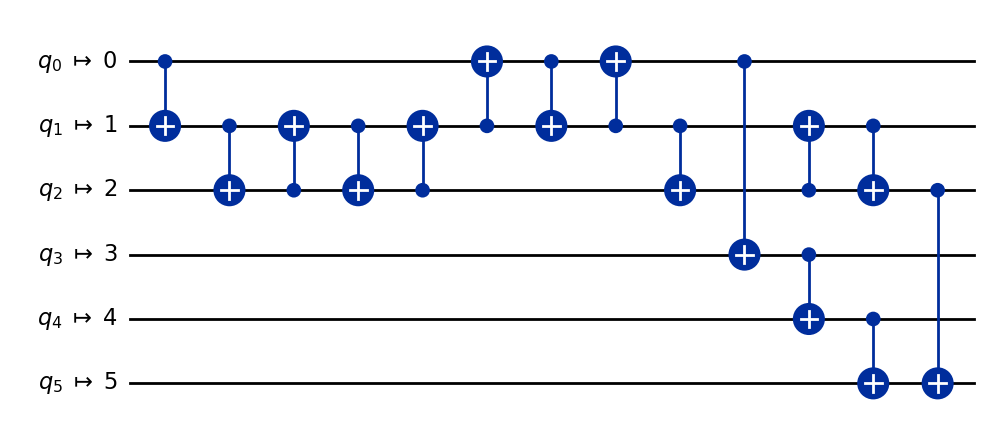

In [1]:
# === The transpilation game, played for real (locally, no cloud) ===
# A small "linear function" block: a chain of CNOTs that entangles q0->q1->...->q5.
# This is the SAME gate family the thesis AI is trained to re-synthesize.
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.transpiler import CouplingMap

# A square-lattice patch = a 2x3 grid with 6 qubits (nodes 0..5):
#   0 - 1 - 2
#   |   |   |
#   3 - 4 - 5
n = 6
grid_edges = [(0,1),(1,2),(0,3),(1,4),(2,5),(3,4),(4,5)]
cmap = CouplingMap(couplinglist=[e for a,b in grid_edges for e in ((a,b),(b,a))])

logical = QuantumCircuit(n, name="linear_block")
for i in range(n - 1):
    logical.cx(i, i + 1)          # a contiguous CNOT block (best case for the AI)
logical.cx(0, n - 1)              # one "long-range" CNOT: corners 0 and 5 are NOT adjacent

# CLASSICAL transpile (QPM): qubit i sits on grid node i (fixed/trivial layout), then
# SABRE routes. Because corners 0 and 5 are far apart, it must insert SWAPs -> CX blows up.
qpm = transpile(logical, coupling_map=cmap, optimization_level=1,
                basis_gates=["cx","rz","sx","x"],
                initial_layout=list(range(n)), layout_method="trivial",
                routing_method="sabre", seed_transpiler=11)

qpm_cx    = qpm.count_ops().get("cx", 0)
qpm_depth = qpm.depth()
print("CLASSICAL (QPM)")
print(f"  two-qubit (CX) gates : {qpm_cx}   (we started with just {n} CNOTs!)")
print(f"  circuit depth        : {qpm_depth}")
qpm.draw("mpl", fold=-1)

AI-STYLE synthesis (SWAP-free, edges only)
  two-qubit (CX) gates : 6   (classical was 15)
  circuit depth        : 5   (classical was 12)

  --> the AI route avoids the SWAP blow-up that the greedy heuristic took.


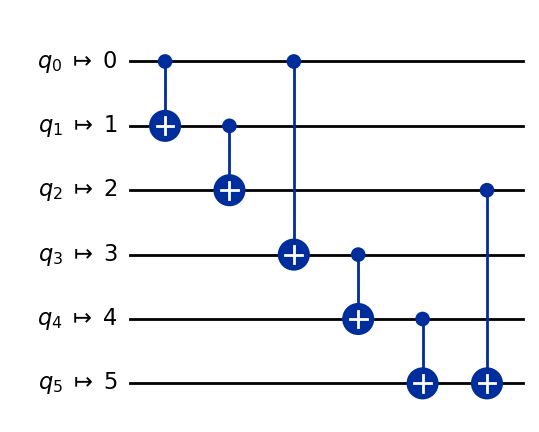

In [ ]:
ai_like = QuantumCircuit(n, name="ai_synth")
# Build the same connectivity using only physically-adjacent pairs (grid edges):
ai_like.cx(0, 1)
ai_like.cx(1, 2)
ai_like.cx(0, 3)            # 0-3 is a real grid edge
ai_like.cx(3, 4)           # walk 0->3->4 instead of SWAP-ing 0 next to 4
ai_like.cx(4, 5)
ai_like.cx(2, 5)

# Same fixed placement as the classical run -> the ONLY difference is SWAP-free synthesis.
ai_like = transpile(ai_like, coupling_map=cmap, optimization_level=1,
                    basis_gates=["cx","rz","sx","x"],
                    initial_layout=list(range(n)), layout_method="trivial",
                    seed_transpiler=11)
ai_cx    = ai_like.count_ops().get("cx", 0)
ai_depth = ai_like.depth()

print("AI-STYLE synthesis (SWAP-free, edges only)")
print(f"  two-qubit (CX) gates : {ai_cx}   (classical was {qpm_cx})")
print(f"  circuit depth        : {ai_depth}   (classical was {qpm_depth})")
print()
print(f"  --> the AI route avoids the SWAP blow-up that the greedy heuristic took.")
ai_like.draw("mpl", fold=-1)

## How does the AI learn to play? (Reinforcement Learning)

Nobody hand-codes the AI's moves. It learns by **trial and error**, the same way
you'd learn a video game:

1. **Try a move** (place a gate).
2. **Get a score** (small penalty for the gate, big bonus if the circuit is now finished).
3. **Adjust** so that moves leading to high scores become more likely next time.
4. **Repeat** millions of times, starting from one-gate puzzles and slowly
   ramping up to hard ones (this is *curriculum learning*: easy levels first).

![The AI plays the synthesis game: it looks at the current circuit-as-a-grid,
its neural network suggests probabilities for each legal gate, it samples one,
the circuit updates, and it repeats until done.](assets/rl_game.png)

The specific recipe (one name to drop, no need to explain the math):
**PPO, Proximal Policy Optimization.** PPO's one trick is *don't change your
strategy too fast after a single lucky game*. It clips each update so the AI
improves steadily instead of forgetting what already worked. It is the standard,
boring, reliable choice for this kind of problem.

**The catch that the whole thesis is about:** the AI only learns the legal moves
**for one chip shape**. Change the wiring, and its move-list is wrong. That is why
a model trained on the old chip can't just be dropped onto the new one. It has to
be **retrained**.

*(Source: thesis 2.4: RL as MDP (state=circuit-as-binary-matrix,
action=place one native CNOT, reward=−gate cost + terminal bonus,
episode=until identity) [printed p.18-23]; PPO clip mechanism [printed p.20];
Fig.10 sequential decision loop [printed p.23]; curriculum learning, difficulty
ramps with qubit count [printed p.21, 42, 46]; per-topology specialization /
must retrain per coupling map [printed p.21, 24].)*